# Machine Learning Modeling: US EV Sales vs. Economic & Public Interest Factors

## Project Overview
This notebook applies machine learning methods to predict electric vehicle (EV) sales in the United States based on fluctuating oil prices, GDP per capita, and public search trends. Four regression models (Linear Regression, kNN, Random Forest, and Decision Tree) are implemented, evaluated, and compared to understand feature importance and market drivers.

## Data Sources & Limitations
| Variable | Source | Notes |
|---|---|---|
| EV Sales (BEV + PHEV) | Argonne National Laboratory | Monthly, 2010–2026 |
| Crude Oil Price (WTI) | Yahoo Finance (yfinance) | Monthly closing price |
| GDP per Capita | FRED (A939RX0Q048SBEA) | Monthly - US |
| Public Interest | Google Trends (CSV) | Search term: *electric car*, US only, 0–100 scale |
| Tariff Dummy | Derived | US tariffs on Chinese EV imports (after 1 May 2024) |

**Limitation Acknowledgment (GDP Data)**: The original GDP data is reported quarterly, while our EV sales data is monthly. To make the datasets match, I used linear interpolation (.interpolate(method='linear')) to fill in the missing months. This means the code drew a straight line between the quarterly GDP numbers to estimate the months in between. While this was necessary to run the models, it is a limitation because it creates "artificial smoothness." Real-world GDP fluctuates unpredictably, but our interpolated data assumes it moved at a perfectly steady, straight rate, which removes some natural variance from our dataset.

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

print("1. Loading EV Sales Data...")
df_ev = pd.read_csv('ev_sales.csv')
df_ev['Date'] = pd.to_datetime(df_ev['Month'], format='%b-%y')
df_ev['Total_EV_Sales'] = df_ev['BEV'] + df_ev['PHEV']
df_ev = df_ev[['Date', 'Total_EV_Sales']].set_index('Date')

print("2. Loading Google Trends Data...")
df_trends = pd.read_csv('multiTimeline.csv', skiprows=2)
df_trends.columns = ['Month', 'Search_Trend']
df_trends['Date'] = pd.to_datetime(df_trends['Month'])
df_trends = df_trends[['Date', 'Search_Trend']].set_index('Date')

print("3. Fetching Oil Prices (WTI Crude)...")
oil_raw = yf.download('CL=F', start='2010-12-01', end='2026-03-01', interval='1mo', auto_adjust=True)
df_oil = oil_raw[['Close']].copy()
df_oil.columns = ['Oil_Price']
df_oil.index = df_oil.index.tz_localize(None).to_period('M').to_timestamp()

print("4. Fetching GDP per Capita...")
df_gdp = web.DataReader('A939RX0Q048SBEA', 'fred', '2010-10-01', '2026-03-01')
df_gdp.columns = ['GDP_per_Capita']
df_gdp.index.name = 'Date'
df_gdp = df_gdp.resample('MS').interpolate(method='linear')

print("5. Merging Datasets...")
df_final = df_ev.join([df_oil, df_trends, df_gdp], how='inner')

# Add Tariff Dummy (1 = tariff active, May 2024 onwards)
df_final['Tariff_Active'] = np.where(df_final.index >= '2024-05-01', 1, 0)

print("\nFinal Dataset Info:")
df_final.info()
display(df_final.head())

[*********************100%***********************]  1 of 1 completed

1. Loading EV Sales Data...
2. Loading Google Trends Data...
3. Fetching Oil Prices (WTI Crude)...
4. Fetching GDP per Capita...


5. Merging Datasets...

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 156 entries, 2010-12-01 to 2026-01-01
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Total_EV_Sales  156 non-null    int64  
 1   Oil_Price       156 non-null    float64
 2   Search_Trend    156 non-null    int64  
 3   GDP_per_Capita  156 non-null    float64
 4   Tariff_Active   156 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 7.3 KB


,Total_EV_Sales,Oil_Price,Search_Trend,GDP_per_Capita,Tariff_Active
Date,,,,,
2010-12-01,345,91.379997,15,54417.000000,0
2011-01-01,424,92.190002,20,54341.000000,0
2011-02-01,364,96.970001,18,54430.666667,0
2011-03-01,906,106.720001,20,54520.333333,0
2011-04-01,1066,113.930000,24,54610.000000,0


## 2. Train/Test Split & Feature Scaling

Because our dataset is a time series, we cannot randomly shuffle the data. We must perform a chronological split to train our models on past data and test them on future data.

**Addressing Scaler Leakage:** To ensure a rigorous and mathematically valid evaluation, it is critical that the model has no "peek" at the testing data. Therefore, the `MinMaxScaler` is strictly `fit` only on the `X_train` dataset. The testing features (`X_test`) are then transformed using the parameters learned exclusively from the training set.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Define Features (X) and Target (y)
X = df_final[['Oil_Price', 'Search_Trend', 'GDP_per_Capita', 'Tariff_Active']]
y = df_final['Total_EV_Sales']

# Chronological Train/Test Split (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training data range: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Testing data range:  {X_test.index.min().date()} to {X_test.index.max().date()}\n")

scaler = MinMaxScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X.columns, index=X_test.index)

print("Scaling complete: No data leakage occurred.")
display(X_train_scaled.head())

Training data range: 2010-12-01 to 2022-12-01
Testing data range:  2023-02-01 to 2026-01-01

Scaling complete: No data leakage occurred.


,Oil_Price,Search_Trend,GDP_per_Capita,Tariff_Active
Date,,,,
2010-12-01,0.762856,0.022989,0.006164,0.0
2011-01-01,0.771375,0.080460,0.000000,0.0
2011-02-01,0.821643,0.057471,0.007273,0.0
2011-03-01,0.924177,0.080460,0.014545,0.0
2011-04-01,1.000000,0.126437,0.021818,0.0


## 3. Machine Learning Modeling & Evaluation

With our features properly scaled and isolated, we will implement four regression models to predict `Total_EV_Sales`.

The models evaluated are:
1. **Linear Regression:** Serves as our baseline parametric model.
2. **k-Nearest Neighbors (kNN):** A non-parametric instance-based learning algorithm.
3. **Random Forest Regressor:** An ensemble method utilizing multiple decision trees to improve predictive accuracy and control over-fitting.
4. **Decision Tree Regressor:** A single tree model that splits the data into feature-based branches, allowing us to easily interpret feature importance.

We evaluate the models using:
* **Root Mean Squared Error (RMSE):** Punishes larger errors more severely.
* **Mean Absolute Error (MAE):** The average absolute difference between predicted and actual sales.
* **R² Score:** Measures how well the model explains the variance compared to a horizontal line.

Training models and evaluating on the test set...

--- Model Performance Results ---


,RMSE (Cars),MAE (Cars),R²
Decision Tree,34276.48,29126.44,-1.18
Random Forest,46517.01,41212.71,-3.02
kNN,53826.33,48997.75,-4.38
Linear Regression,57381.74,52971.25,-5.11


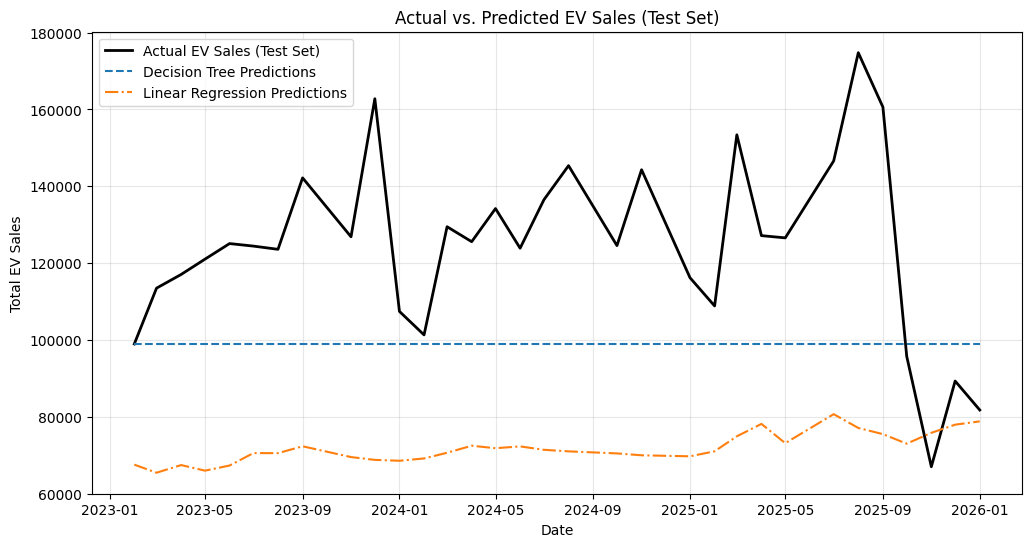

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Initialize the 4 models
models = {
    "Linear Regression": LinearRegression(),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

# Dictionaries to store predictions and metrics
predictions = {}
evaluation_metrics = {}

print("Training models and evaluating on the test set...\n")

for name, model in models.items():
    # 1. Train the model
    model.fit(X_train_scaled, y_train)

    # 2. Predict on the test set
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # 3. Calculate readable evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store metrics
    evaluation_metrics[name] = {'RMSE (Cars)': rmse, 'MAE (Cars)': mae, 'R²': r2}

# Create a DataFrame to display the results cleanly
results_df = pd.DataFrame(evaluation_metrics).T
results_df = results_df.sort_values(by='MAE (Cars)', ascending=True)

print("--- Model Performance Results ---")
display(results_df.round(2))

# --- Visualization to explain the negative R2 ---
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual EV Sales (Test Set)', color='black', linewidth=2)

# Plot the predictions for the best performing model and Linear Regression
plt.plot(y_test.index, predictions["Decision Tree"], label='Decision Tree Predictions', linestyle='--')
plt.plot(y_test.index, predictions["Linear Regression"], label='Linear Regression Predictions', linestyle='-.')

plt.title('Actual vs. Predicted EV Sales (Test Set)')
plt.ylabel('Total EV Sales')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.1 Results, Interpretation & Conclusion

**1. Model Performance & The "Negative R²" Phenomenon**
All models yielded exceptionally high error metrics and negative R² scores on the testing data. A negative R² indicates that the models performed worse than a simple horizontal line. This is not a computational error, but a direct consequence of using a chronological train/test split on a market that suddenly exploded.

**2. The Extrapolation Limitation (Tree-Based Models)**
The plotted predictions reveal a fundamental limitation of tree-based algorithms (Decision Tree, Random Forest): they are mathematically incapable of extrapolation. They cannot output a value higher than the absolute maximum observed in their pre-2023 training data. Because the EV market experienced an unprecedented boom entirely contained within the test period (2023–2026), these models simply "flatlined" at their historical ceiling.

**3. Conclusion & Real-World Insight**
While the machine learning models "failed" to achieve high accuracy, this failure provides a crucial real-world insight: The US EV market underwent a massive paradigm shift around 2023. The factors that drove slow, early EV adoption (like steady GDP growth and oil prices) are no longer the primary drivers. The failure of the models to predict the recent boom proves that the modern EV market is being driven by external "X-factors" not captured in our dataset.

**4. Limitations & Future Work**
To improve this analysis in the future, two key extensions could be explored:
* **Specialized Time-Series Models:** Instead of standard machine learning regression, future iterations should utilize dedicated time-series forecasting models designed specifically to predict future trends based on past sequential timelines.
* **Feature Engineering for Market Shifts:** The dataset should be enriched with new variables that reflect recent market changes, such as the introduction of major government tax credits (e.g., the Inflation Reduction Act), the declining cost of lithium-ion batteries, and the increasing number of available EV models.